<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/A01840476_Actividad4EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: JOSEGREG DE JESUS TOVAR BLANCO
*   MATRÍCULA: A01840476

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [101]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pandas.plotting import scatter_matrix

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
sns.set(style="whitegrid") #Para tener un mejor efecto visual de grid
plt.rcParams["figure.figsize"] = (8,5) #Para homogenizar los gráficos

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [44]:
loan_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/personal_loan.csv")
loan_df.head()


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,0,25,1,49,91108,4,1.6,1.0,0,0,Yes,No,0,0
1,1,45,19,34,90089,3,1.5,1.0,0,No,Yes,No,No,0
2,2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,3,35,9,100,94112,1,2.7,2.0,0,0,0,0,No,0
4,4,35,8,45,91330,4,1.0,2.0,0,0,No,No,0,1


In [45]:
loan_df.set_index("ID", inplace=True) #Para facilitar la limpieza y analisis y no tratar el indice como una variable
loan_df.info()

#Contamos columnas por tipo

loan_df.dtypes.value_counts()



<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB


,count
int64,6
object,5
float64,2


Originalmente:

float64(2 Columnas)

int64(6 Columnas)

object(5 Columnas)

# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [46]:
loan_df[loan_df["Age"] > 100]


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


In [47]:
#Si existieron valores mayores a 100 entonces los eliminamos:

loan_df_original = loan_df.copy() #hacemos una copia del original
filas_iniciales = loan_df.shape[0]

#ahora si filtramos por las que sean mayores de 100 años.

loan_df = loan_df[loan_df["Age"] <= 100]

Ahora hace sentido eliminar otras variables que considero que pueden tener errores:



1.   Valores de dinero negativos (como ingresos, hipotecas, etc)
2.   Experiencia laboral tambien negativas o que no hagan sentido con la edad cronologica
3. Rangos Exagerados
4. Variables mal codificadas

In [48]:
#Primero filtramos los valores mas obvios, por ejemplo los que no pueden ser negativos:

loan_df = loan_df[
    (loan_df["Income"] >= 0) &
    (loan_df["Experience"] >= 0) &
    (loan_df["Mortgage"] >= 0)
]

#Podemos ahora ver rangos raros con ayuda de los percentiles

loan_df["Income"].describe(percentiles=[0.90, 0.95, 0.99, 0.999])
loan_df.sort_values("Income", ascending=False).head(20)


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
3896,48,24,224,93940,2,6.67,1.0,0,No,No,Yes,Yes,Yes
4993,45,21,218,91801,2,6.67,1.0,0,No,0,0,Yes,0
526,26,2,205,93106,1,6.33,1.0,271,0,0,No,No,1
2988,46,21,205,95762,2,8.80,1.0,181,No,1,No,Yes,0
2278,30,4,204,91107,2,4.50,1.0,0,0,0,No,Yes,0
677,46,21,204,92780,2,2.80,1.0,0,0,0,No,1,0
5010,43,18,204,91902,2,8.80,1.0,0,0,No,0,1,0
4225,43,18,204,91902,2,8.80,1.0,0,0,No,0,1,0
5020,35,5,203,95032,1,10.00,3.0,0,Yes,No,No,No,0


No se observan valores de ingresos fuera de rango o desproporcion

In [49]:
#Veamos edad vs experiencia porque no deberia haber personas con una experiencia de
 # muchos años a una corta edad suponiendo que maximo trabaje la persona desde los 18 años

loan_df[loan_df["Experience"] > loan_df["Age"] - 18]


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,


No hay inconsistencias


In [50]:
#Variables mal codificadas:

binary_cols = [
    "Personal Loan",
    "Securities Account",
    "CD Account",
    "Online",
    "CreditCard"
]

for col in binary_cols:
    print(col, loan_df[col].unique())


Personal Loan ['0' 'No' 'Yes' '1']
Securities Account ['Yes' '0' 'No' '1']
CD Account ['No' '0' '1' 'Yes']
Online ['0' 'No' '1' 'Yes']
CreditCard ['0' '1' 'Yes' 'No']


Todo Ok con las variables, aunque hay que hacer limpieza para estandarizar


In [51]:
#Ahora si analizamos el impacto de los filtrados

filas_finales = loan_df.shape[0]

deleted = filas_iniciales - filas_finales
percentage = (deleted / filas_iniciales) * 100

display(deleted, percentage)


56

1.111772880682946

Se eliminaron en total 56 Filas con este análisis, lo que representa un 1.11% del total original del dataframe

3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [52]:
#Transformar todo a 0 y 1

for col in binary_cols:
    print("\n", col)
    print(loan_df[col].value_counts(dropna=False))

binary_map = {
    "Yes": 1, "No": 0,
    "yes": 1, "no": 0,
    "Y": 1, "N": 0,
    "y": 1, "n": 0,
    1: 1, 0: 0
}

for col in binary_cols:
    loan_df[col] = loan_df[col].replace(binary_map)

for col in binary_cols:
    loan_df[col] = pd.to_numeric(loan_df[col], errors="coerce")

for col in binary_cols:
    print(col, loan_df[col].unique())




 Personal Loan
Personal Loan
0      3477
No     1018
Yes     368
1       118
Name: count, dtype: int64

 Securities Account
Securities Account
No     2695
0      1766
Yes     391
1       129
Name: count, dtype: int64

 CD Account
CD Account
No     2463
0      2214
1       163
Yes     141
Name: count, dtype: int64

 Online
Online
Yes    1701
No     1629
1      1277
0       374
Name: count, dtype: int64

 CreditCard
CreditCard
0      2628
Yes     910
No      886
1       557
Name: count, dtype: int64
Personal Loan [0 1]
Securities Account [1 0]
CD Account [0 1]
Online [0 1]
CreditCard [0 1]


In [54]:
#Ahora detectemos columnas tipo object otra vez
text_cols = loan_df.select_dtypes(include=["object", "string"]).columns.tolist()
print(text_cols)


for col in text_cols:
    print(f"\n--- {col} ---")
    print(loan_df[col].value_counts(dropna=False).head(20))



[]


El dataset no contiene variables categóricas de tipo texto de forma nativa.
Sin embargo el código postal (ZIP Code) se trata como variable nominal, por lo que será convertida explícitamente a tipo string para su análisis categorico

4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [57]:
duplicados = loan_df.duplicated().sum()
display(duplicados)
loan_df[loan_df.duplicated()].head(50)


np.int64(36)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
5000,47,21,42,95841,4,0.1,1.0,0,0,0,0,1,1
5001,64,40,169,91320,2,2.1,1.0,122,0,0,0,1,0
5002,44,18,68,93943,4,2.9,1.0,0,0,1,0,0,0
5004,63,39,49,90275,1,0.8,1.0,103,0,0,0,1,0
5005,35,11,24,95521,4,0.4,2.0,0,0,0,0,0,0
5006,53,28,14,94005,4,0.8,1.0,0,0,0,0,1,1
5007,37,13,79,91330,1,3.6,2.0,104,0,0,0,1,0
5008,45,21,91,95054,1,4.7,1.0,0,0,0,0,1,0
5009,51,25,175,90089,3,0.7,1.0,312,1,0,0,0,0


In [60]:
#Verificacion

dup_rows = loan_df[loan_df.duplicated(keep=False)]
dup_rows

dup_rows.sort_values(by=loan_df.columns.tolist()).head(10)


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
1160,28,1,40,95134,1,2.0,2.0,0,0,1,0,1,0
5031,28,1,40,95134,1,2.0,2.0,0,0,1,0,1,0
3673,34,9,65,95134,4,1.3,1.0,0,0,0,0,0,1
5032,34,9,65,95134,4,1.3,1.0,0,0,0,0,0,1
2101,35,5,203,95032,1,10.0,3.0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026,64,37,138,94709,2,2.8,2.0,0,1,0,0,1,0
767,64,39,38,92024,1,1.1,3.0,108,0,0,0,0,0
5016,64,39,38,92024,1,1.1,3.0,108,0,0,0,0,0


In [61]:
#Eliminamos los duplicados:

filas_antes2 = loan_df.shape[0]

loan_df = loan_df.drop_duplicates()

filas_despues2 = loan_df.shape[0]

print("Duplicados eliminados:", filas_antes2 - filas_despues2)


Duplicados eliminados: 36


In [62]:
#Reseteamos el indice:

loan_df = loan_df.reset_index(drop=True)

#Verificacion final:

loan_df.head()
loan_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 4945 non-null   int64  
 1   Experience          4945 non-null   int64  
 2   Income              4945 non-null   int64  
 3   ZIP Code            4945 non-null   int64  
 4   Family              4945 non-null   int64  
 5   CCAvg               4945 non-null   float64
 6   Education           4945 non-null   float64
 7   Mortgage            4945 non-null   int64  
 8   Personal Loan       4945 non-null   int64  
 9   Securities Account  4945 non-null   int64  
 10  CD Account          4945 non-null   int64  
 11  Online              4945 non-null   int64  
 12  CreditCard          4945 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 502.4 KB


5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [66]:
#Convertimos:

loan_df["ZIP Code"] = loan_df["ZIP Code"].astype("object") #codigo postal a object

loan_df["Education"] = loan_df["Education"].astype("category") #edcuation a category

loan_df["Education"] = loan_df["Education"].cat.set_categories(
    [1, 2, 3],
    ordered=True
)

loan_df[binary_cols] = loan_df[binary_cols].astype("category")


In [68]:
#verificamos todas:

changed_cols = [
    "Personal Loan",
    "Securities Account",
    "CD Account",
    "Online",
    "CreditCard",
    "Education",
    "ZIP Code"
]

loan_df[changed_cols].dtypes

loan_df[[
    "ZIP Code",
    "Education",
    "Personal Loan",
    "Securities Account",
    "CD Account",
    "Online",
    "CreditCard"
]].info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ZIP Code            4945 non-null   object  
 1   Education           4944 non-null   category
 2   Personal Loan       4945 non-null   category
 3   Securities Account  4945 non-null   category
 4   CD Account          4945 non-null   category
 5   Online              4945 non-null   category
 6   CreditCard          4945 non-null   category
dtypes: category(6), object(1)
memory usage: 68.5+ KB


Las variables fueron convertidas de acuerdo con su naturaleza estadística. El código postal (ZIP Code) se trató como variable nominal al no presentar orden ni magnitud, el nivel educativo se convirtió a variable ordinal, especificando explícitamente el orden 1 < 2 < 3. Finalmente, las variables binarias relacionadas con productos financieros y la variable objetivo se trataron como categóricas, al representar estados discretos sin magnitud numérica.

In [79]:
#Creamos las listas para el tipo de variable:

#numericals

num_cols = loan_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numericals")
display(num_cols)

#Crear cat_cols (variables categóricas)

cat_cols = loan_df.select_dtypes(
    include=["category", "object", "string"]
).columns.tolist()

print("Categoricals")
display(cat_cols)


Numericals


['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']

Categoricals


['ZIP Code',
 'Education',
 'Personal Loan',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [80]:
loan_df[num_cols].describe() #Estadisticas basicas

#Luego añadimos Curtosis y asimetria

stats_num = loan_df[num_cols].describe().T

stats_num["skewness"] = loan_df[num_cols].skew()
stats_num["kurtosis"] = loan_df[num_cols].kurt()

stats_num



,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,4945.0,45.558948,11.317222,24.0,36.0,46.0,55.0,67.0,-0.023185,-1.161376
Experience,4945.0,20.332861,11.308864,0.0,11.0,20.0,30.0,43.0,-0.015611,-1.134468
Income,4945.0,73.817391,46.120046,8.0,39.0,64.0,98.0,224.0,0.842040,-0.047616
Family,4945.0,2.390091,1.151588,-3.0,1.0,2.0,3.0,4.0,0.136545,-1.309572
CCAvg,4945.0,1.935907,1.748143,0.0,0.7,1.5,2.6,10.0,1.594416,2.634932
Mortgage,4945.0,56.617796,101.846873,0.0,0.0,0.0,101.0,635.0,2.105137,4.766282


Analisis de los resultados:


### 1.   Edad: (AGE)
Simetrica - Platicurtica

Distribución altamente simétrica (media casi igual que mediana).No hay sesgo relevante hacia jóvenes ni hacia mayores. Curtosis negativa indica una distribución más plana que la normal lo que indica menos concentración extrema y edades bien repartidas, Se podria decir que es una variable “limpia” y bien comportada.

### 2.    Ingresos: (INCOME)

Asimetrica Positiva - mesocurtica

Media mayor que mediana, es asimetría positiva moderada, hay clientes con ingresos altos que empujan la media. Curtosis cercana a 0 indica de forma similar a normal, sin colas extremas exageradas. es una variable robusta que indica muchos clientes medios.

### 4. Hipoteca (MORTGAGE)

Fuertemente asimetrica positiva - Leptocurtica

Mediana igual 0 o sea que más del 50% no tiene hipoteca, esto genera una Asimetría positiva muy alta y una curtosis extremadamente alta se esperaria colas muy pesadas. Requiere tratamiento especial (segmentación, transformación o análisis separado)




7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

In [90]:
#Primero paleta de colores:

FOREST_GREEN = "#006400"   # verde bosque
FOREST_PALETTE = ["#008000", "#138808", "#388E3C", "#4CAF50"]

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.edgecolor": FOREST_GREEN,
        "axes.labelcolor": FOREST_GREEN,
        "xtick.color": FOREST_GREEN,
        "ytick.color": FOREST_GREEN,
        "text.color": FOREST_GREEN,
        "axes.titleweight": "bold"
    }
)

### **Histogramas con curvas de KDE y distribución normal**

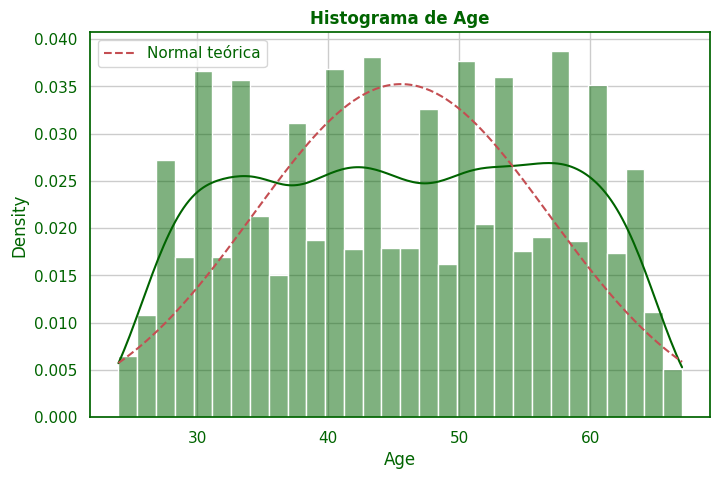

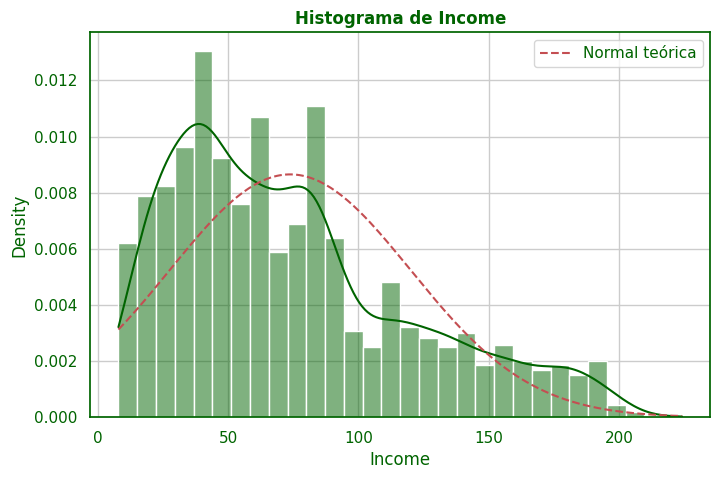

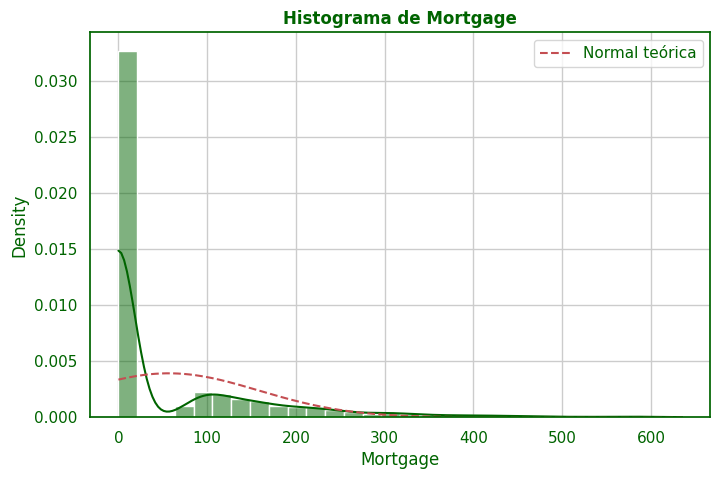

In [91]:



#histogramas con curvas de KDE y Distribucion normal

var_interes = ["Age", "Income", "Mortgage"]

for col in var_interes:
    data = loan_df[col].dropna()
    plt.figure()

    sns.histplot(
        data,
        bins=30, #para una distribucion con los rangos evaluados
        kde=True,
        stat="density",
        color=FOREST_GREEN,
        edgecolor="white"
    )

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    plt.plot(x, norm.pdf(x, mu, sigma), "r--", label="Normal teórica")

    plt.title(f"Histograma de {col}")
    plt.legend()
    plt.show()

**Conclusión:** Si las graficas totalmente coinciden con lo esperado.

### **Gráficos Boxplots**

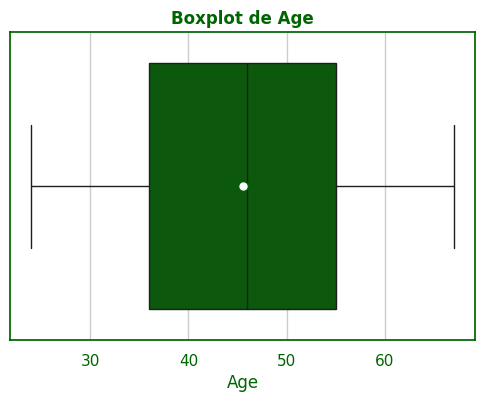

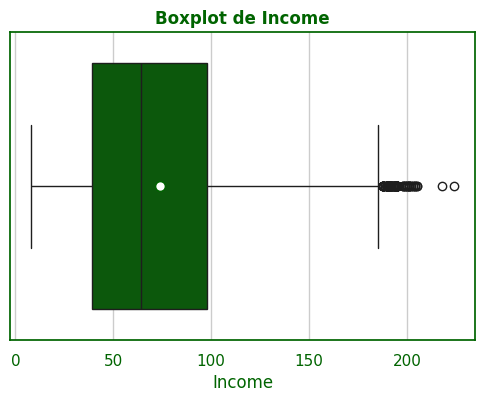

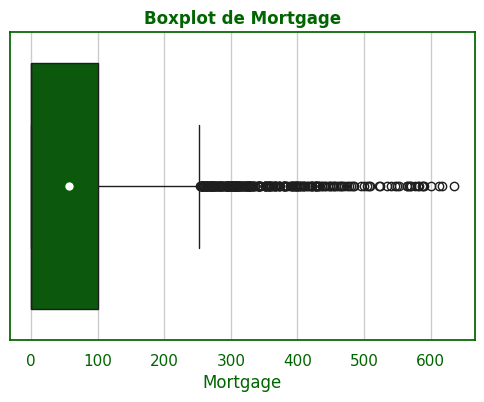

In [104]:
for col in var_interes:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=loan_df[col],
        color=FOREST_GREEN,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": FOREST_GREEN,
            "markersize": 7
        }
    )

    plt.title(f"Boxplot de {col}")
    plt.show()


### **Conclusión:**

Analizando las gráficas confirma lo observado en la data:

Partimos de que la comparación entre la media y la mediana permite identificar el sesgo (asimetría) de la distribución de cada variable. Cuando la media y la mediana presentan valores similares, la distribución puede considerarse aproximadamente simétrica. Así podemos concluir:

En el caso de **Age**, la media y la mediana se encuentran prácticamente alineadas, lo que confirma una distribución simétrica, sin un sesgo significativo hacia valores bajos o altos. Esto es consistente con el valor de asimetría cercano a cero calculado previamente

Para **Income**, la media se sitúa por encima de la mediana, lo que evidencia un sesgo positivo (asimetría a la derecha) Esto indica que existen algunos valores elevados de ingreso que incrementan la media, mientras que la mayoría de los clientes presenta ingresos cercanos a la mediana, dato interesante

En la variable **Mortgage**, la diferencia entre la media y la mediana es mucho más marcada, ya que la mediana es igual a cero mientras que la media toma un valor considerablemente mayor. Esta relación refleja una asimetría positiva pronunciada causada por una alta concentración de valores bajos o nulos y una cola derecha extensa formada por hipotecas de gran monto. Esta variable debe analizarse en conjunto a otras

En conjunto, la posición relativa de la media respecto a la mediana confirma los patrones de asimetría observados en el análisis numérico ya respondido en la seccion anterior, validando que Age es aproximadamente simétrica, Income presenta asimetría positiva moderada y Mortgage muestra una asimetría positiva fuerte.

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

In [93]:
loan_df[cat_cols].describe()


,ZIP Code,Education,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,4945,4944,4945,4945,4945,4945,4945
unique,468,3,2,2,2,2,2
top,94720,1,0,0,0,1,0
freq,164,2079,4465,4429,4643,2954,3490


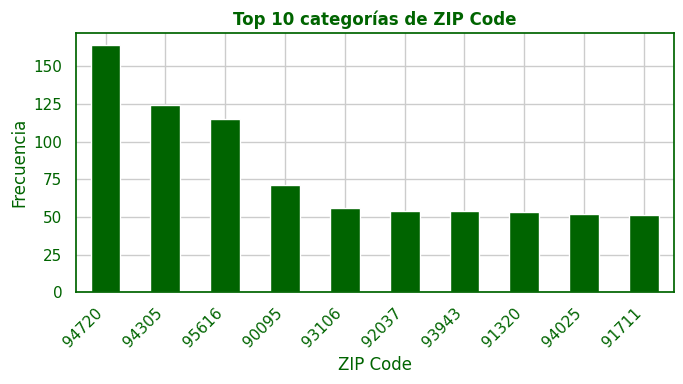

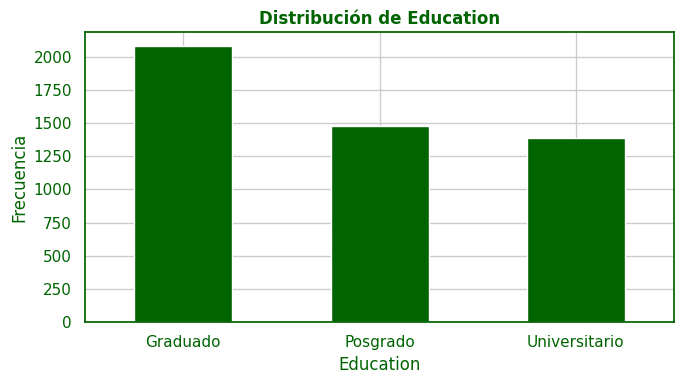

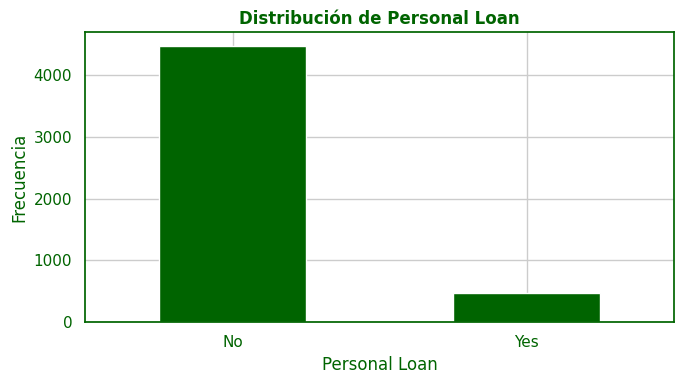

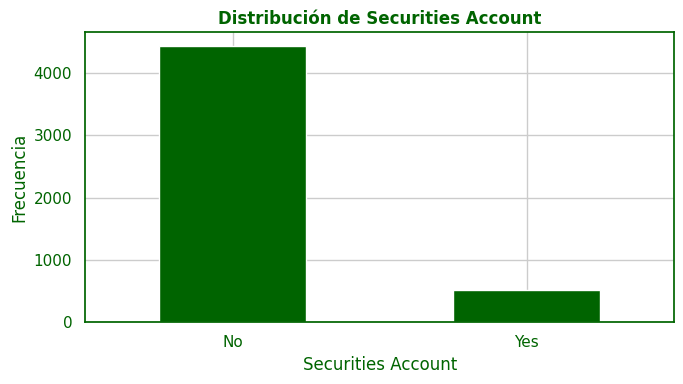

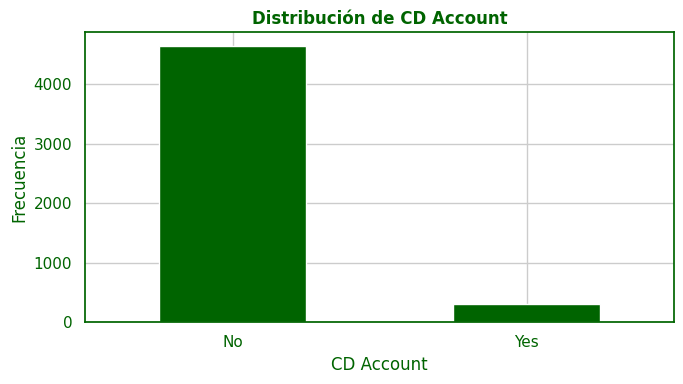

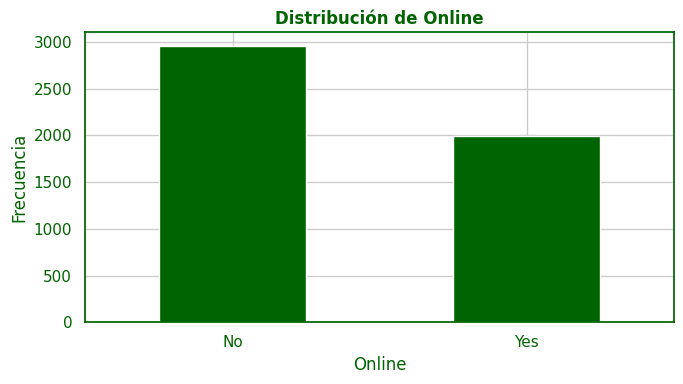

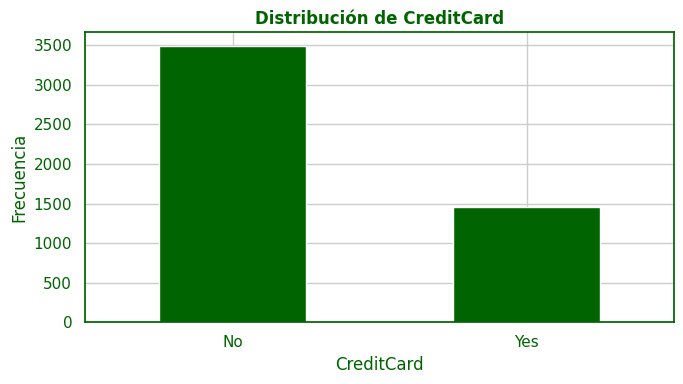

In [99]:
for col in cat_cols:

    counts = loan_df[col].value_counts()

    # Alta cardinalidad top 10
    if counts.shape[0] > 10:
        counts = counts.head(10)
        title = f"Top 10 categorías de {col}"
    else:
        title = f"Distribución de {col}"

    plt.figure(figsize=(7,4))
    ax= counts.plot(
        kind="bar",
        color=FOREST_GREEN,
        edgecolor="white"
    )

    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

     #CAMBIO CLAVE: etiquetas Sí / No SOLO PARA BINARIAS y Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)

    education_labels = {
    1: "Graduado",
    2: "Universitario",
    3: "Posgrado"}
    if set(counts.index) == {0, 1}:
        ax.set_xticklabels(["No", "Yes"], rotation=0)
    elif col == "Education":
        labels = [education_labels.get(i, str(i)) for i in counts.index]
        ax.set_xticklabels(labels, rotation=0)
    else:
        plt.xticks(rotation=45, ha="right")



    plt.tight_layout()
    plt.show()


# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

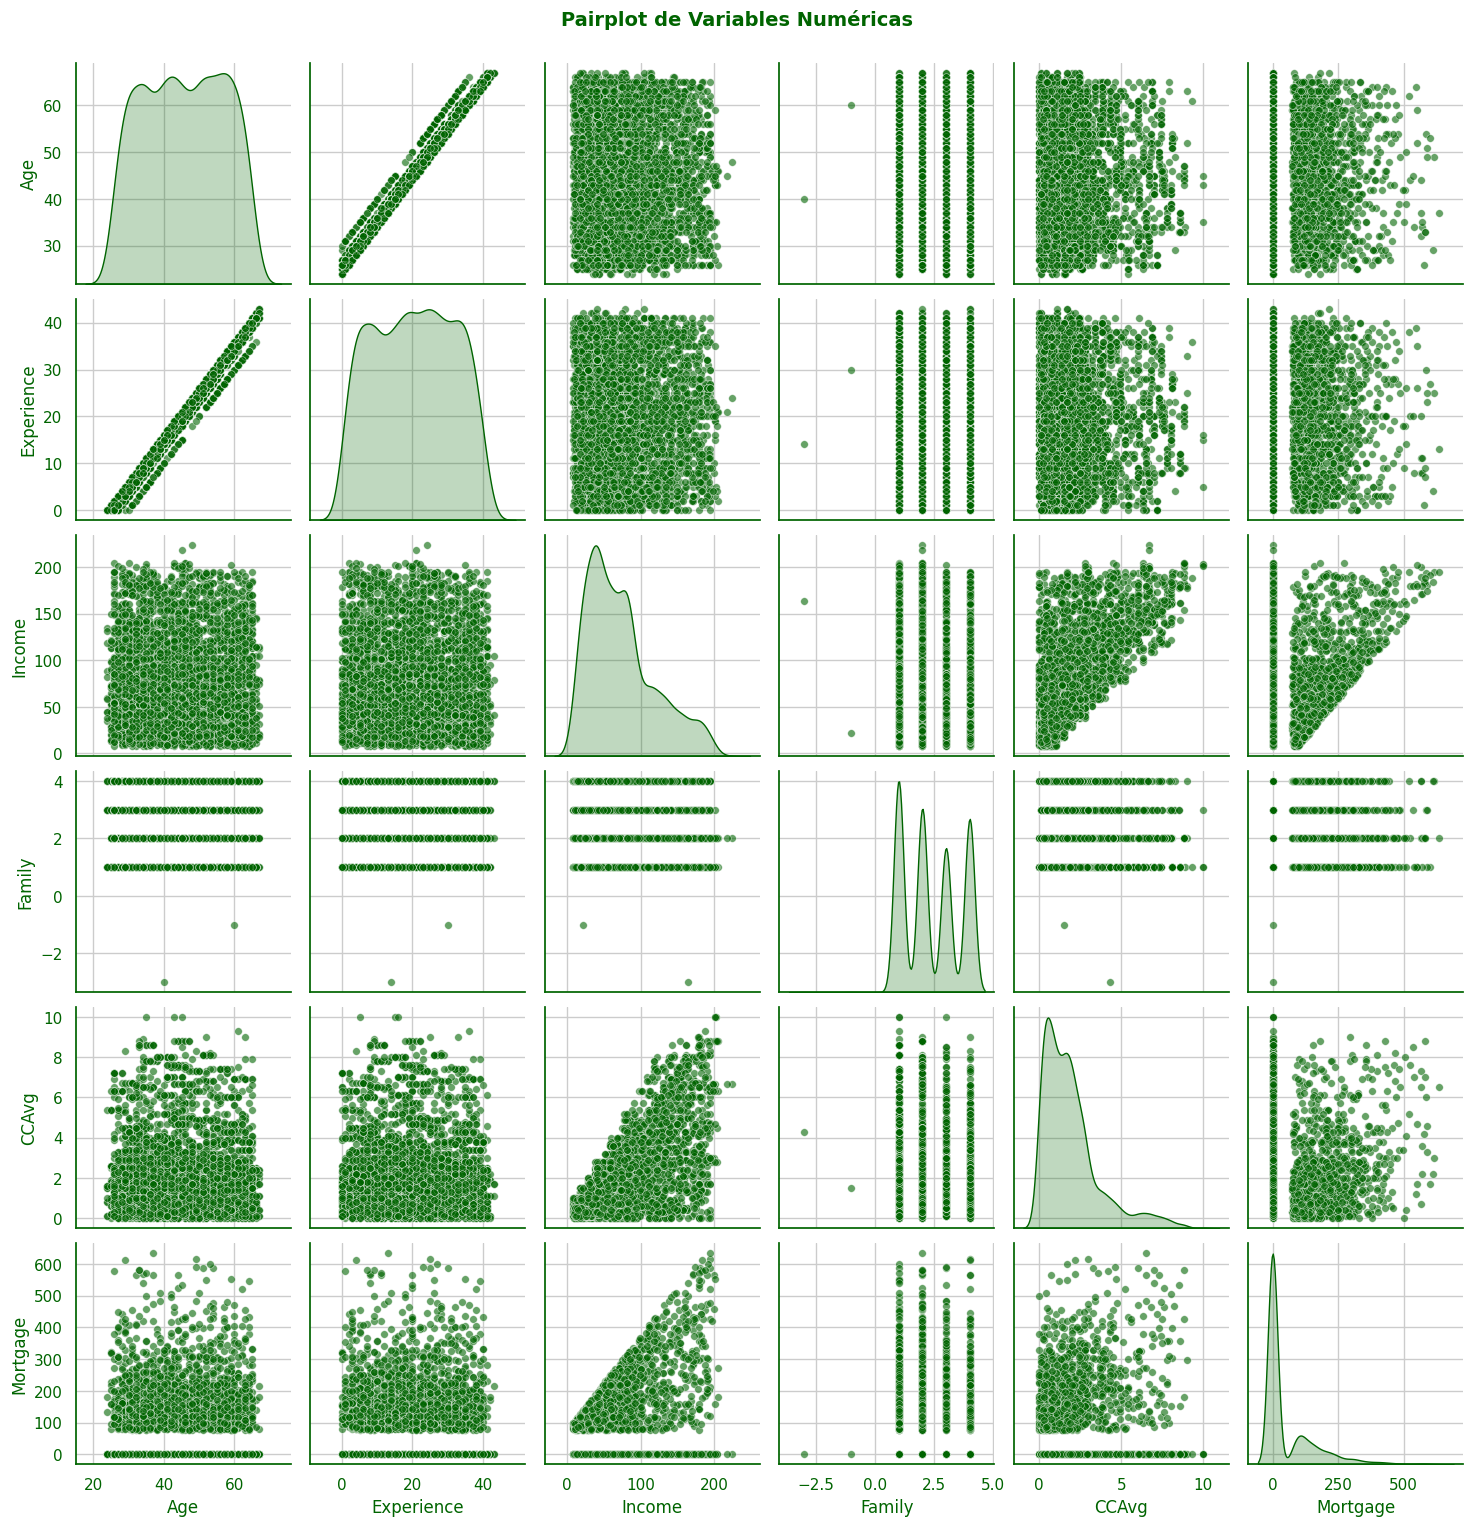

In [106]:
#Scatter Matrix con seaborn

sns.pairplot(
    loan_df[num_cols],
    diag_kind="kde",          # KDE en la diagonal
    plot_kws={
        "color": FOREST_GREEN,
        "alpha": 0.6,
        "s": 30
    },
    diag_kws={
        "color": FOREST_GREEN,
        "fill": True
    }
)

plt.suptitle(
    "Pairplot de Variables Numéricas",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.show()


### **Análisis**:

La matriz de dispersión generada mediante pairplot permite visualizar de manera simultánea la distribución individual de cada variable numérica y sus relaciones bivariadas. Se observan patrones claros entre edad y experiencia laboral, así como una relación positiva entre ingreso y gasto con tarjeta de crédito.

adicionalmente el pairplot permite identificar variables cuyo valor analítico no reside en la correlación directa, sino en su comportamiento estructural: en particular, Mortgage destaca como una variable cero-inflada y altamente asimétrica, lo que sugiere la coexistencia de dos subpoblaciones claramente diferenciadas: clientes sin hipoteca y clientes con montos de hipoteca variables y, en algunos casos, elevados. Este patrón indica que Mortgage debe analizarse de manera segmentada o mediante transformaciones específicas, ya que su inclusión directa en análisis lineales puede ocultar relaciones relevantes con variables como Income o CCAvg.

Por otra parte variables como Family, aun cuando no muestran asociaciones bivariadas fuertes con las demás variables numéricas, resultan relevantes desde la perspectiva de calidad de datos. Su comportamiento discreto y la presencia de valores atípicos o inconsistentes evidencian la necesidad de un tratamiento cuidadoso previo al modelado. Asimismo, variables como CCAvg, aunque no exhiben una relación lineal fuerte con todas las variables, muestran una dispersión creciente en combinación con Income y Mortgage, lo que las convierte en candidatas relevantes para análisis posteriores orientados a segmentación de clientes o predicción del comportamiento financiero.

### **Correlacion de Pearson**

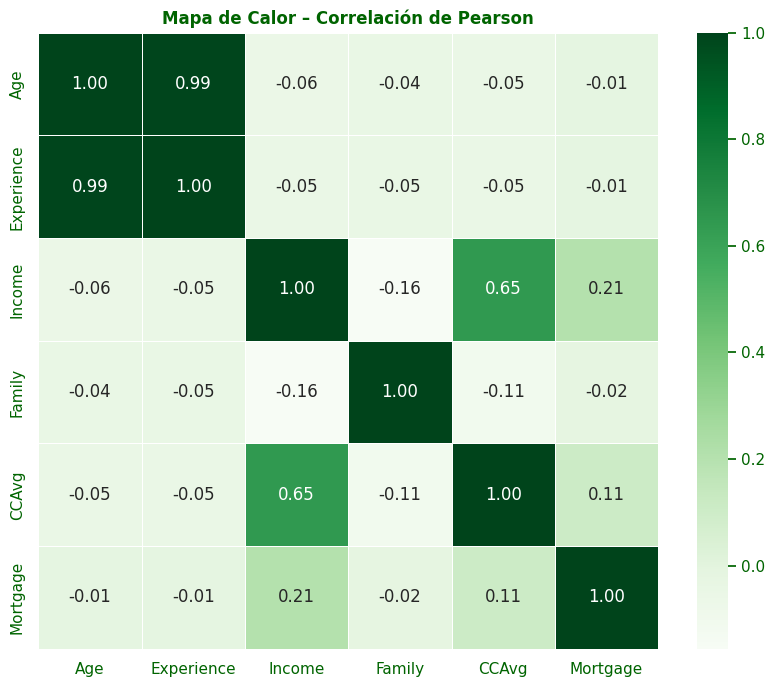

In [109]:
corr_matrix = loan_df[num_cols].corr(method="pearson")

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5
)

plt.title("Mapa de Calor – Correlación de Pearson")
plt.show()

### **Análisis:**

El mapa de calor de correlación de Pearson evidencia que la única relación lineal fuerte entre las variables numéricas es la existente entre Age y Experience, con un coeficiente cercano a 1. Esta correlación casi perfecta confirma que ambas variables capturan información altamente redundante, lo cual es coherente ya que la experiencia laboral aumenta naturalmente con la edad. Desde el punto de vista analítico y de modelado, este resultado sugiere la conveniencia de no utilizar ambas variables simultáneamente, con el fin de evitar problemas de multicolinealidad y simplificar la interpretación de los modelos posteriores.

Por otro lado, se observa una correlación positiva moderada entre Income y CCAvg, lo que indica que los clientes con mayores ingresos tienden a presentar un mayor gasto promedio con tarjeta de crédito. Esta relación es consistente tanto con la lógica económica como con los patrones visuales observados en el pairplot. En contraste, la mayoría de las demás relaciones presentan coeficientes bajos o cercanos a cero, particularmente aquellas que involucran la variable Mortgage, lo que confirma que su comportamiento altamente asimétrico y cero-inflado dificulta la captura de relaciones lineales mediante la correlación de Pearson.

En conjunto, el heatmap refuerza la idea de que solo algunas relaciones lineales son relevantes, mientras que otras variables requerirán análisis segmentado o métodos no lineales para revelar patrones más informativos

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


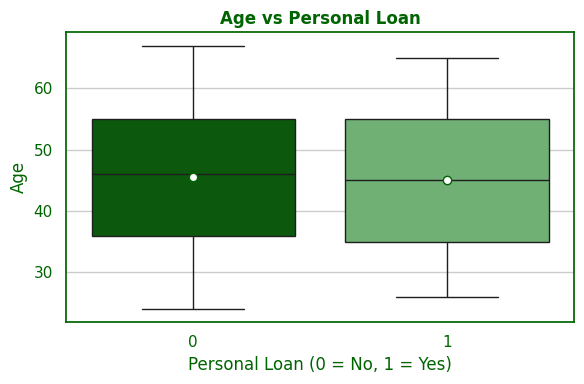

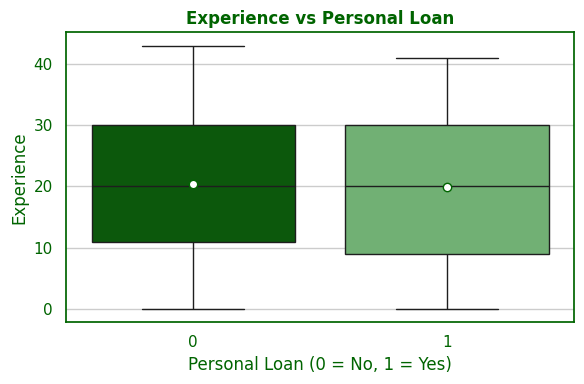

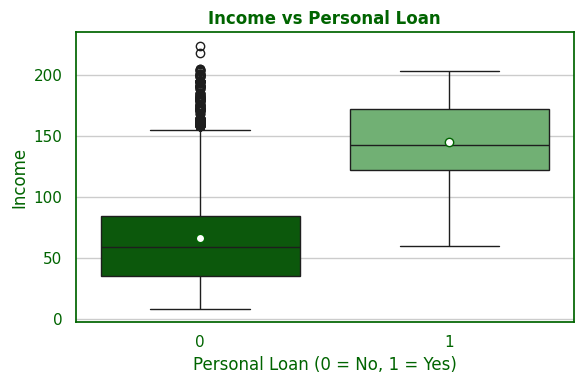

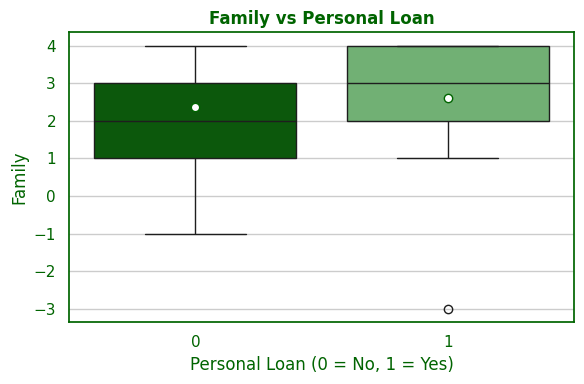

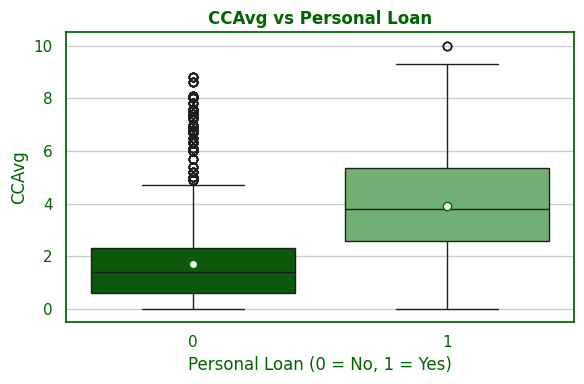

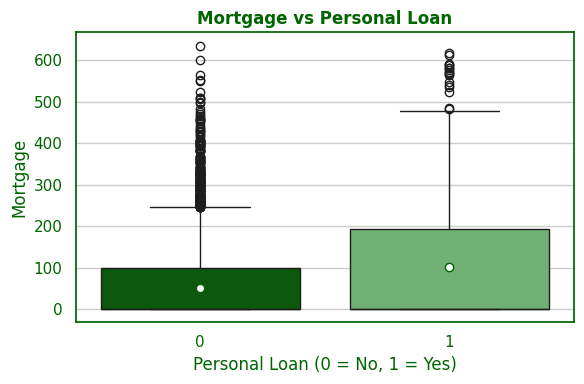

In [118]:
for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="Personal Loan",
        y=col,
        hue="Personal Loan",
        data=loan_df,
        palette=[FOREST_GREEN, "#66BB6A"],
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": FOREST_GREEN
        },
        legend=False
    )

    plt.title(f"{col} vs Personal Loan")
    plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
    plt.tight_layout()
    plt.show()


### **Análisis:**

El análisis de las variables numéricas mediante boxplots revela diferencias claras entre los clientes que aceptaron el préstamo personal y aquellos que no. En particular, Income y CCAvg muestran un desplazamiento significativo de la mediana y de la media hacia valores más altos en el grupo que aceptó el préstamo, lo que indica que los clientes con mayor capacidad económica y mayor gasto con tarjeta tienen una mayor probabilidad de aceptación. Mortgage presenta valores más elevados y mayor dispersión en el grupo positivo, sugiriendo que los clientes con compromisos financieros previos tienden a aceptar con mayor frecuencia el préstamo. En contraste, variables como Age y Family no muestran una separación clara entre ambos grupos, lo que sugiere un poder discriminante limitado desde el punto de vista numérico.

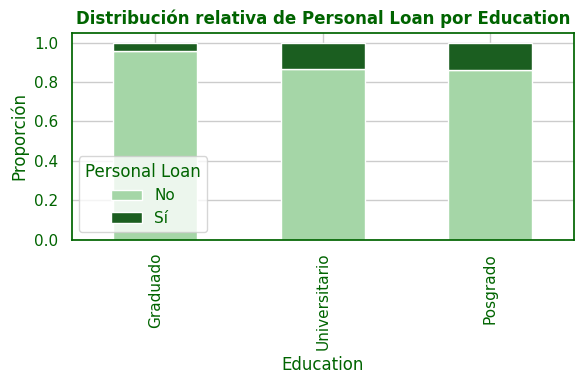

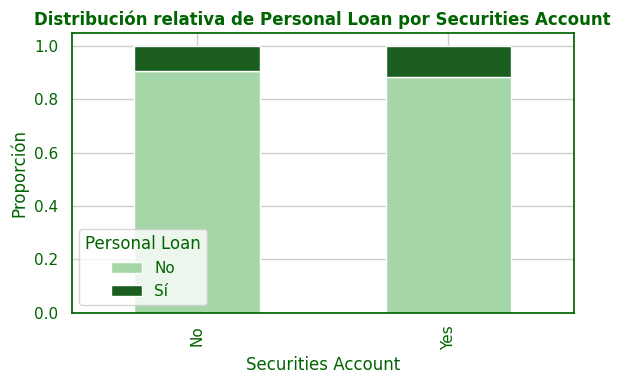

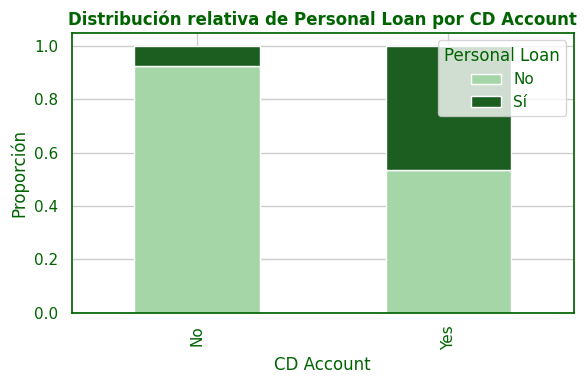

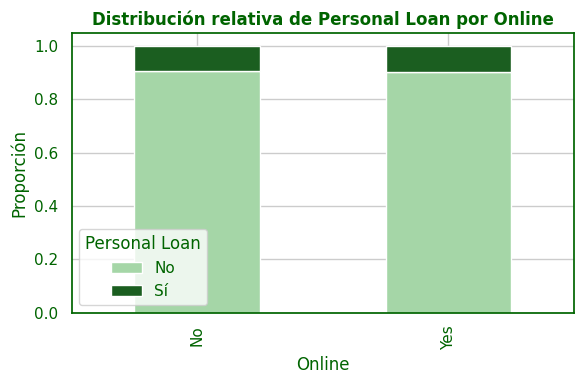

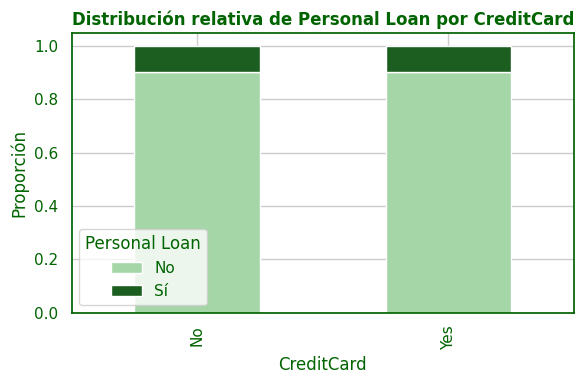

In [117]:
#Variables categoricas mas relevantes que concentran mas "SI"

cat_cols = loan_df.select_dtypes(
    include=["category", "object", "string"]
).columns.tolist()

cat_cols = [c for c in cat_cols if c not in ["ZIP Code", "Personal Loan"]]

# Cambiar nombres a binarias: 0 / 1 → No / Sí
binary_labels = {
    0: "No",
    1: "Yes"
}

for col in cat_cols:
    prop_df = (
        loan_df
        .groupby(col, observed=True)["Personal Loan"]
        .value_counts(normalize=True)
        .unstack()
    )

    # --- CAMBIO CLAVE: renombrar SOLO PARA LA GRÁFICA ---
    if col == "Education":
        prop_df.index = prop_df.index.map(education_labels)
    else:
        # Binarias
        prop_df.index = prop_df.index.map(binary_labels)

    ax = prop_df.plot(
        kind="bar",
        stacked=True,
        color=["#A5D6A7", "#1B5E20"],
        figsize=(6,4)
    )

    ax.set_title(f"Distribución relativa de Personal Loan por {col}")
    ax.set_ylabel("Proporción")
    ax.set_xlabel(col)

    # Leyenda clara
    ax.legend(["No", "Sí"], title="Personal Loan")

    plt.tight_layout()
    plt.show()




### **Análisis:**

Se evidencia patrones relevantes en la aceptación del préstamo. El nivel educativo (Education) muestra una proporción creciente de aceptación conforme aumenta el grado de estudios, destacando los clientes con posgrado como el grupo con mayor participación relativa de respuestas positivas. De igual forma, las variables asociadas a productos financieros, como CD Account y Securities Account, presentan una mayor proporción de aceptación del préstamo, lo que sugiere que los clientes con una relación financiera más profunda con la institución son más propensos a contratar nuevos productos.